In [31]:
# ==========================================
# CELL 1: ALL LIBRARY IMPORTS (At the very top)
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv('job_salary_prediction_dataset.csv')
df.head()


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


## Section 1: Data Preprocessing & Baseline Model (All Features)


In [33]:

# 1. Convert categorical text columns into numbers using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Separate features (X) and target variable (y)
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

# 3. Split the dataset into Train and Test sets with an 80/20 ratio and fixed random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Multiple Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Predict salaries on the unseen test data
y_pred_lr = lr_model.predict(X_test)

# 6. Calculate and print the R2 Score for the Multiple Linear Regression model
print("Real Dataset Multiple Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))

Real Dataset Multiple Linear Regression R2 Score: 0.9634690228446962


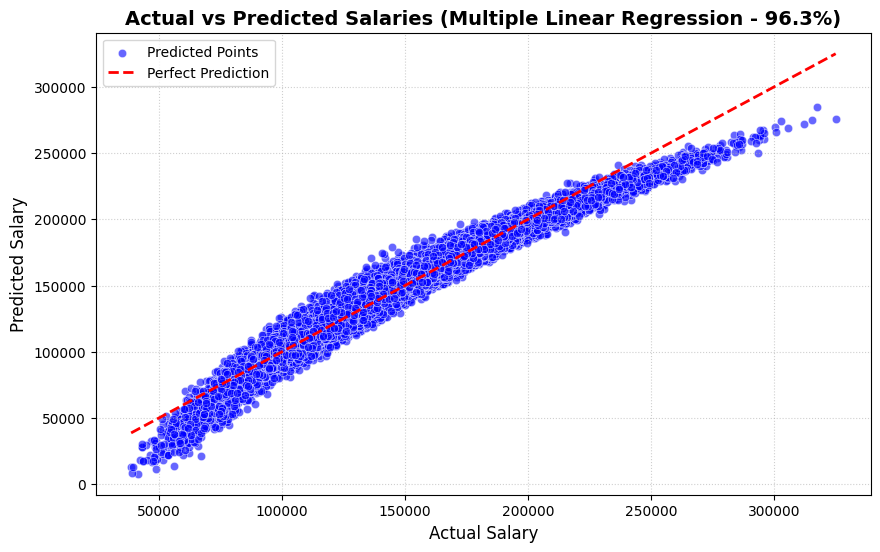

In [34]:

# 1. Set the figure size for the plot
plt.figure(figsize=(10, 6))

# 2. Create a scatter plot for Actual vs Predicted salaries
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue', alpha=0.6, label='Predicted Points')

# 3. Plot a perfect 45-degree diagonal reference line (Best Fit / Perfect Prediction Line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 4. Add title, labels, and customize the plot appearance
plt.title('Actual vs Predicted Salaries (Multiple Linear Regression - 96.3%)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Salary', fontsize=12)
plt.ylabel('Predicted Salary', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Display the final plot
plt.show()

## Section 2: Experimentation - Feature Selection (77.7% Accuracy)

In [35]:


# 1. Select all useful features (Both numerical and categorical)
features = ['experience_years', 'education_level', 'job_title', 'industry', 'location', 'certifications']
X = df[features]
y = df['salary']

# 2. Convert text columns into numbers using One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=['education_level', 'job_title', 'industry', 'location'], drop_first=True)

# 3. Split the newly encoded data into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Train the Multiple Linear Regression model
optimized_model = LinearRegression()
optimized_model.fit(X_train, y_train)

# 5. Make predictions and check the new accuracy
y_pred_opt = optimized_model.predict(X_test)
print("Optimized R2 Score (New Accuracy):", r2_score(y_test, y_pred_opt))

Optimized R2 Score (New Accuracy): 0.777586873053133


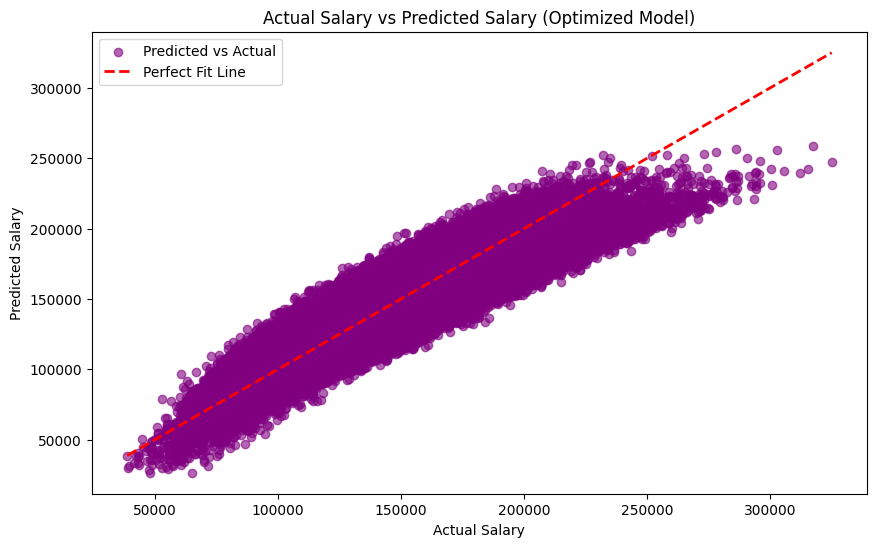

In [36]:


plt.figure(figsize=(10, 6))

# Plotting Actual vs Predicted values
plt.scatter(y_test, y_pred_opt, color='purple', alpha=0.6, label='Predicted vs Actual')

# Plotting the perfect prediction line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit Line')

plt.title('Actual Salary vs Predicted Salary (Optimized Model)')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.show()

In [37]:
# 1. Extract the very first row (index 0) from the Test set as our sample input
sample_input = X_test.iloc[[0]]

# 2. Use the trained optimized model to predict the salary for this specific sample
predicted_salary = optimized_model.predict(sample_input)[0]

# 3. Fetch the actual (real) salary for this same sample from the target test set
actual_salary = y_test.iloc[0]

# 4. Print both the values to compare the model's guess with reality
print("--- PREDICTION TEST ---")
print(f"Model Predicted Salary : ${predicted_salary:,.2f}")
print(f"Actual Salary in Data  : ${actual_salary:,.2f}")

# 5. Calculate and print the absolute difference (prediction error)
difference = abs(actual_salary - predicted_salary)
print(f"Difference (Error)     : ${difference:,.2f}")

--- PREDICTION TEST ---
Model Predicted Salary : $195,598.20
Actual Salary in Data  : $164,009.00
Difference (Error)     : $31,589.20


## Section 3: Alternative Model - Decision Tree Regressor (53.2% Accuracy)

In [38]:
# 1. Convert categorical text columns into numbers using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Separate features (X) and target variable (y)
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

# 3. Split the dataset into Train and Test sets with an 80/20 ratio and fixed random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the Decision Tree model (Set max_depth=5 to prevent overfitting)
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# 5. Train the model on the training dataset
dt_model.fit(X_train, y_train)

# 6. Predict salaries on the unseen test data
y_pred_dt = dt_model.predict(X_test)

# 7. Calculate and print the R2 Score for the Decision Tree model
print("Real Dataset Decision Tree R2 Score:", r2_score(y_test, y_pred_dt))

Real Dataset Decision Tree R2 Score: 0.5320708217073437


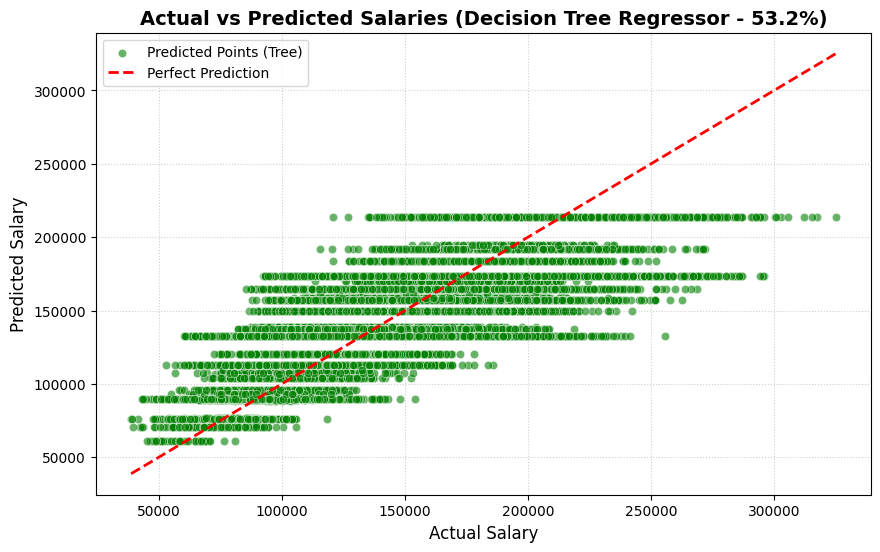

In [39]:


# 1. Set the figure size for the Decision Tree plot
plt.figure(figsize=(10, 6))

# 2. Create a scatter plot for Actual vs Predicted salaries (Decision Tree)
sns.scatterplot(x=y_test, y=y_pred_dt, color='green', alpha=0.6, label='Predicted Points (Tree)')

# 3. Plot the perfect 45-degree diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 4. Add title, labels, and customize the plot appearance
plt.title('Actual vs Predicted Salaries (Decision Tree Regressor - 53.2%)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Salary', fontsize=12)
plt.ylabel('Predicted Salary', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Display the final plot
plt.show()